<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
#!pip install pandas
#!pip install matplotlib
#!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


                      Software Development 41.30%
                                    Other: 10.66%
                                   Fintech  5.69%
Internet, Telecomm or Information Services  5.64%
                Banking/Financial Services  4.75%
                                Healthcare  4.43%
                             Manufacturing  4.38%
              Retail and Consumer Services  4.38%
                                Government  3.33%
              Media & Advertising Services  3.10%
                          Higher Education  3.08%
           Transportation, or Supply Chain  2.98%
      Computer Systems Design and Services  2.92%
                                    Energy  2.00%
                                 Insurance  1.35%


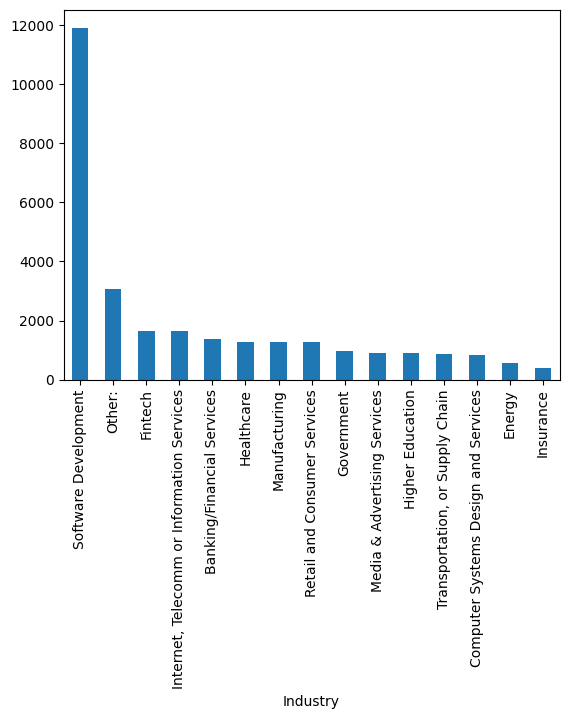

In [37]:
##Write your code here
ind_vc = df['Industry'].value_counts()
ind_vc.plot(kind='bar')
for idx,value in ind_vc.items():
    print(f"{idx:>42} {value / ind_vc.sum()*100:>5.2f}%")

### Notable comments of mine
The Software Development category should not necessarily be interpreted as the size of software industry. It more likely reflects how respondents classified the industry or business in which they work.
If we would comprehensively category Fintech, Banking/Financial Services and Insurance into financial service industry, then the ratio would be 11.79%. This value looks big. Moreover bigger because the securities category was not presented and people who work in the securities industry might choose Software Development or Other.

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [49]:
##Write your code here
des = df['ConvertedCompYearly'].describe()
des

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

In [59]:
avg = des['mean']
std = des['std']
u_outlier = df.loc[(df['ConvertedCompYearly']>avg+3*std)|(df['ConvertedCompYearly']<avg-3*std),'ConvertedCompYearly']
u_outlier.describe()

count    8.900000e+01
mean     1.623895e+06
std      2.366560e+06
min      6.500000e+05
25%      7.500000e+05
50%      1.000000e+06
75%      1.332930e+06
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [74]:
##Write your code here
q1 = des['25%']
q2 = des['50%']
q3 = des['75%']
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"IQR = {iqr}, Lower Bound = {lower_bound}, Upper Bound = {upper_bound}")

IQR = 75259.5, Lower Bound = -80177.25, Upper Bound = 220860.75


<Axes: >

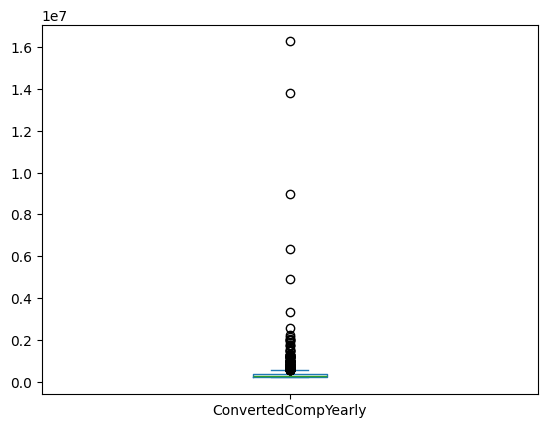

In [75]:
u_outlier = df.loc[df['ConvertedCompYearly'] > upper_bound,'ConvertedCompYearly']
u_outlier.plot(kind='box')

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


<Axes: >

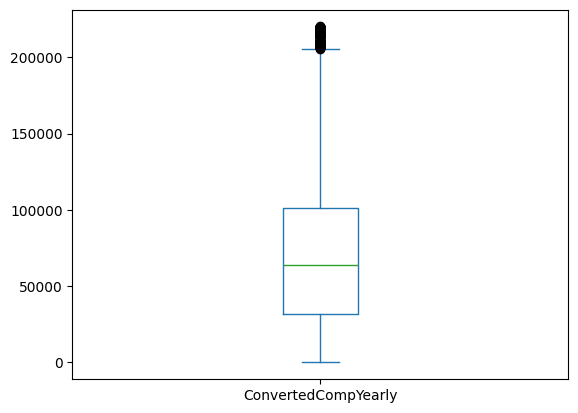

In [77]:
##Write your code here
df_c = df.loc[df['ConvertedCompYearly'] < upper_bound,'ConvertedCompYearly']
df_c.plot(kind='box')

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [3]:
#df.columns[(df.dtypes=='float')|(df.dtypes=='int')]
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols
# WorkExp, JobSatPoints_?, ConvertedCompYearly, JobSat

Index(['ResponseId', 'CompTotal', 'WorkExp', 'JobSatPoints_1',
       'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7',
       'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10',
       'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat'],
      dtype='object')

In [4]:
df['Age'].isna().sum()

np.int64(0)

In [5]:
df['Age'].value_counts()

Age
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: count, dtype: int64

In [6]:
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 65
}
df['Age_numeric'] = df['Age'].map(age_mapping)
df['Age_numeric']

0        17.0
1        39.0
2        49.0
3        21.0
4        21.0
         ... 
65432    21.0
65433    29.0
65434    29.0
65435    21.0
65436    21.0
Name: Age_numeric, Length: 65437, dtype: float64

Age_numeric
17.0    7.175676
21.0    6.720958
29.0    6.870472
39.0    7.014845
49.0    7.135399
59.0    7.303462
65.0    7.890756
Name: JobSat, dtype: float64


<Axes: xlabel='Age_numeric'>

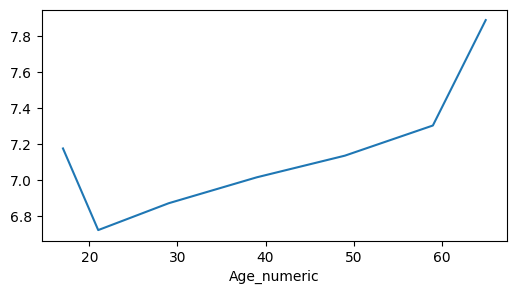

In [7]:
print(df.groupby('Age_numeric')['JobSat'].mean())
df.groupby('Age_numeric')['JobSat'].mean().plot(kind='line', figsize=(6,3))

<Axes: xlabel='Age_numeric'>

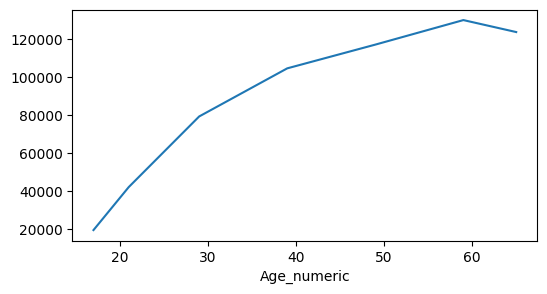

In [9]:
df.groupby('Age_numeric')['ConvertedCompYearly'].mean().plot(kind='line', figsize=(6,3))

             Age_numeric   WorkExp
Age_numeric     1.000000  0.851666
WorkExp         0.851666  1.000000


<Axes: xlabel='Age_numeric', ylabel='WorkExp'>

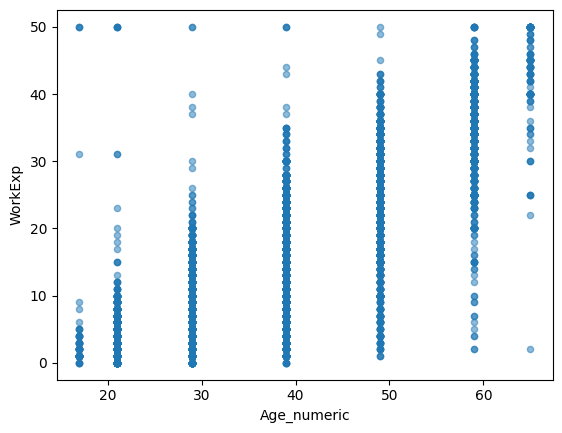

In [14]:
##Write your code here
aw_corr = df[['Age_numeric','WorkExp']].corr()
print(aw_corr)
df[['Age_numeric','WorkExp']].plot(kind='scatter', y='WorkExp', x='Age_numeric', alpha=0.5)

In [104]:
df.to_csv('Survey-data.csv')

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
